In [ ]:
"""
add notagen corpus
"""
from music21 import *
notagen_corpus = corpus.corpora.LocalCorpus("notagen")
notagen_corpus.addPath(r"~\notagen-pieces\scores\Baroque_BachJohannSebastian_Choral")
notagen_corpus.save()
for path in notagen_corpus.getPaths():
    score = corpus.parse(path) # is that a way to iterate over our notagen corpus?

"""
import libraries
"""
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
"""
1. Keys:
Algorithms: determine key of chorale by applying music21's key finding algorithm.
- count how often each key occurs, e.g.
bach_keys = { "C": 23, "C#": 1. "D": 12, ..."c": 32, "c#": 2, ...}
notagen_keys = { "C": 58, "C#": 1. "D": 6, ..."c": 14, "c#": 2, ...}

2. Time signatures:
Algorithm: take first time signature
bach_tss = { "4/4": 23, "3/4": 1. "5/8": 0, ...}
notagen_tss = { "4/4": 58, "3/4": 1. "5/8": 1, ...}

3. Melodies:
Algorithm:
  - transpose everything to C major / a minor (Bach AND Notagen)
  - take only 10 first notes of Soprano

4. Dominant seventh chords
...

5. Parallel Fiths (Google search)

6. Dv / Neapolitaner
...

7. Auftakte / Volltakte
"""

In [6]:
"""
1. Keys:
Count how often each key occurs for bach and notagen
"""
import music21 as m21
from collections import Counter
keys_BACH = []
keys_notagen = []

# BACHkeys
bach_chorales = m21.corpus.chorales.Iterator()
for c in bach_chorales:
    chorales_key = c.analyze("key")
    keys_BACH.append(f"{chorales_key.tonic.name} {chorales_key.mode}")
keys_total = Counter(keys_BACH)
bach_keys = keys_total

# NOTAGENkeys
for path in notagen_corpus.getPaths():
    score = m21.corpus.parse(path)
    ai_keys = score.analyze("key")
    keys_notagen.append(f"{ai_keys.tonic.name} {ai_keys.mode}")
ai_keys = Counter(keys_notagen)


# convert Counter to pandas DataFrame
df_keys = (
    pd.DataFrame({
        "Bach": bach_keys,
        "Notagen": ai_keys
    })
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(columns={"index": "key_name"})
)

df_keys # convert to df 1 column feature (key) 2nd column count bach, 3rd column
df_keys["key_name"] = df_keys["key_name"].str.replace("-", "b")


In [ ]:
# ADD KEY PLOT
COLORS = ["#9a5ea1", "#98823c"]  # colorblind-friendly

def plot_diverging_bars(df, save: str=None, colors=COLORS):
  df = df.sort_values(by="Bach")

  _, axes = plt.subplots(1, 2, sharey=True)
  axes[0].barh(df.iloc[:, 0], df["Bach"], label="Bach", color=colors[0], align="center")
  axes[0].set_title(f"Bach (n={df["Bach"].sum()})")
  axes[0].invert_xaxis()
  axes[0].yaxis.tick_right()

  axes[1].barh(df.iloc[:, 0], df["Notagen"], label="Notagen", color=colors[1])
  axes[1].set_title(f"Notagen (n={df["Notagen"].sum()})")
  # axes[1].set_xlim(0, max_val * 1.1)  ## only uncomment if we have the same number of Notagen pieces as Bach

  for i, ax in enumerate(axes):
    xlim = max([p.get_width() for p in ax.patches]) * 1.2
    for rect in ax.patches:
      x = rect.get_width()
      y = rect.get_y() + rect.get_height() / 2
      offset = -1 if i == 0 else 1
      ax.annotate(
          x,
          (x, y),
          ha="right" if i == 0 else "left",
          va="center",
          color="black",
          fontsize=12,
          xytext=(offset * 5, 0),
          textcoords="offset points",
      )
    factor = 1.35
    if i == 0:
      ax.set_xlim(xlim, 0)
    else:
      ax.set_xlim(0, xlim)

  plt.subplots_adjust(wspace=.2)
  plt.tight_layout()
  if save:
    plt.savefig(save)
  plt.show()


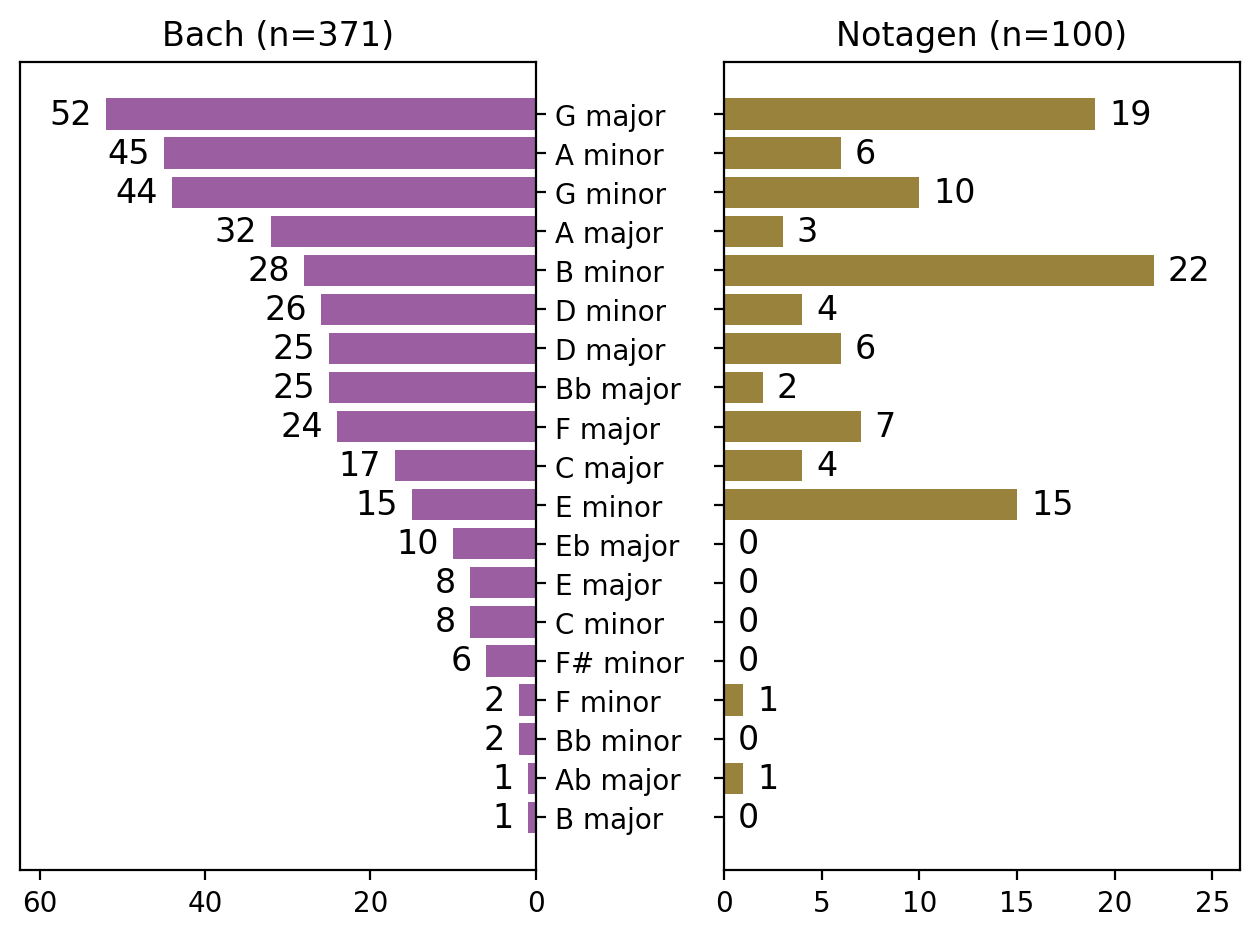

In [8]:
plot_diverging_bars(df_keys, save="key_comparison.pdf")

In [9]:
"""
2. Time signatures:
"""
from collections import Counter

# BACH

bach_tss_list = []
bach_chorales = m21.corpus.chorales.Iterator()
for piece in bach_chorales:
    time_sig = piece.recurse().getElementsByClass(m21.meter.TimeSignature)[0]
    bach_tss_list.append(time_sig.ratioString)
bach_tss = Counter(bach_tss_list)

# NOTAGEN
notagen_tss_list = []
for path in notagen_corpus.getPaths():
    score = m21.corpus.parse(path)
    time_sig = score.recurse().getElementsByClass(m21.meter.TimeSignature)[0]
    notagen_tss_list.append(time_sig.ratioString)
notagen_tss = Counter(notagen_tss_list)

# convert Counter to df

df_tss = (
    pd.DataFrame({
        "Bach": bach_tss,
        "Notagen": notagen_tss
    })
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(columns={"index": "tss"})
)
df_tss

,tss,Bach,Notagen
0,3/4,38,0
1,4/4,331,100
2,3/2,1,0
3,12/8,1,0


In [ ]:
"""
3. Melodies:
Algorithm:
  - transpose everything to C major / a minor (Bach AND Notagen)
  - take only 10 first notes of Soprano
"""
import music21 as m21
count = 0
def extract_snippets(corpus=None):
  if corpus is not None:
    snippets = {}
    rem_snippets = []
    for chorale in corpus:
      try:
        ## transpose to C
        key = chorale.analyze("key")
        if key.mode == "major":
          interval = m21.interval.Interval(key.tonic, m21.pitch.Pitch("C"))
        elif key.mode == "minor":
          interval = m21.interval.Interval(key.tonic, m21.pitch.Pitch("A"))
        else:
          print("error")

        transposed = chorale.transpose(interval)
        for part in chorale.parts:
          if part.partName == "Soprano": # does that work? We should do smell-tests
            id = transposed.metadata.movementName
            soprano = transposed.recurse().notes # <--- we needed recurse instead of flatten! i dont know why, but with flatten the transposed snippets were not right
            # notes = [note.pitch.nameWithOctave for note in soprano.notes][:10]
            notes = [note.pitch.midi for note in soprano.notes][:10]
            snippets[id] = notes
          else:
            print(part.partName) # rem_snippets[id]
      except:
        # print("except", chorale)
        pass

    return snippets
  else:
    return None

bach_chorales = m21.corpus.chorales.Iterator()
bach_snippets = extract_snippets(corpus=bach_chorales)
bach_snippets

In [20]:
def extract_notagen_snippets(corpus=None):
  if corpus is not None:
    snippets = {}
    for chorale in corpus.getPaths():
      chorale = m21.corpus.parse(chorale)
      try:
        ## transpose to C
        key = chorale.analyze("key")
        if key.mode == "major":
          interval = m21.interval.Interval(key.tonic, m21.pitch.Pitch("C"))
        elif key.mode == "minor":
          interval = m21.interval.Interval(key.tonic, m21.pitch.Pitch("A"))
        else:
          print("error")

        transposed = chorale.transpose(interval)
        women_parts = transposed.recurse().getElementsByClass(m21.stream.Part)["Women"] # filter out the men-parts
        soprano = stream.Part() # add a new soprano part
        for v in women_parts.recurse().getElementsByClass(m21.stream.Voice): #filter the Women-Parts by Voices
          if v.id == "1": # Voice 1 is the Soprano we want to extract.
            for n in v.recurse().notes: # appending the notes of Voice 1 to our new Soprano Part
              soprano.append(n)

        notes = [note.pitch.midi for note in soprano.notes]
        snippets[transposed.metadata.movementName] = notes[:10]

      except:
        print("except", chorale)
        pass
    return snippets
notagen_snippets = extract_notagen_snippets(notagen_corpus)
notagen_snippets

{'output1.xml': [72, 72, 71, 69, 67, 72, 72, 71, 72, 72],
 'output10.xml': [64, 65, 67, 67, 65, 64, 62, 62, 64, 66],
 'output100.xml': [64, 67, 65, 64, 62, 64, 66, 67, 67, 64],
 'output11.xml': [69, 69, 71, 72, 71, 76, 74, 72, 71, 72],
 'output12.xml': [69, 69, 71, 72, 71, 76, 74, 72, 71, 72],
 'output13.xml': [76, 76, 74, 72, 71, 69, 76, 78, 79, 76],
 'output14.xml': [64, 60, 62, 64, 65, 67, 67, 69, 67, 65],
 'output15.xml': [76, 76, 81, 80, 81, 76, 74, 76, 77, 76],
 'output16.xml': [76, 76, 74, 72, 71, 76, 74, 72, 71, 72],
 'output17.xml': [69, 69, 71, 72, 71, 68, 64, 72, 71, 69],
 'output18.xml': [60, 60, 62, 64, 62, 64, 65, 64, 62, 60],
 'output19.xml': [60, 67, 67, 67, 67, 69, 67, 65, 64, 62],
 'output2.xml': [76, 76, 76, 76, 81, 81, 81, 80, 76, 79],
 'output20.xml': [69, 69, 71, 72, 71, 76, 74, 72, 71, 72],
 'output21.xml': [69, 64, 69, 69, 71, 67, 66, 66, 64, 60],
 'output22.xml': [60, 67, 67, 67, 67, 69, 67, 65, 64, 62],
 'output23.xml': [60, 60, 67, 67, 65, 64, 62, 64, 65, 64]

Total D7-Chord Count (Bach): 2831
Total D7-Chord Count (Notagen): 574


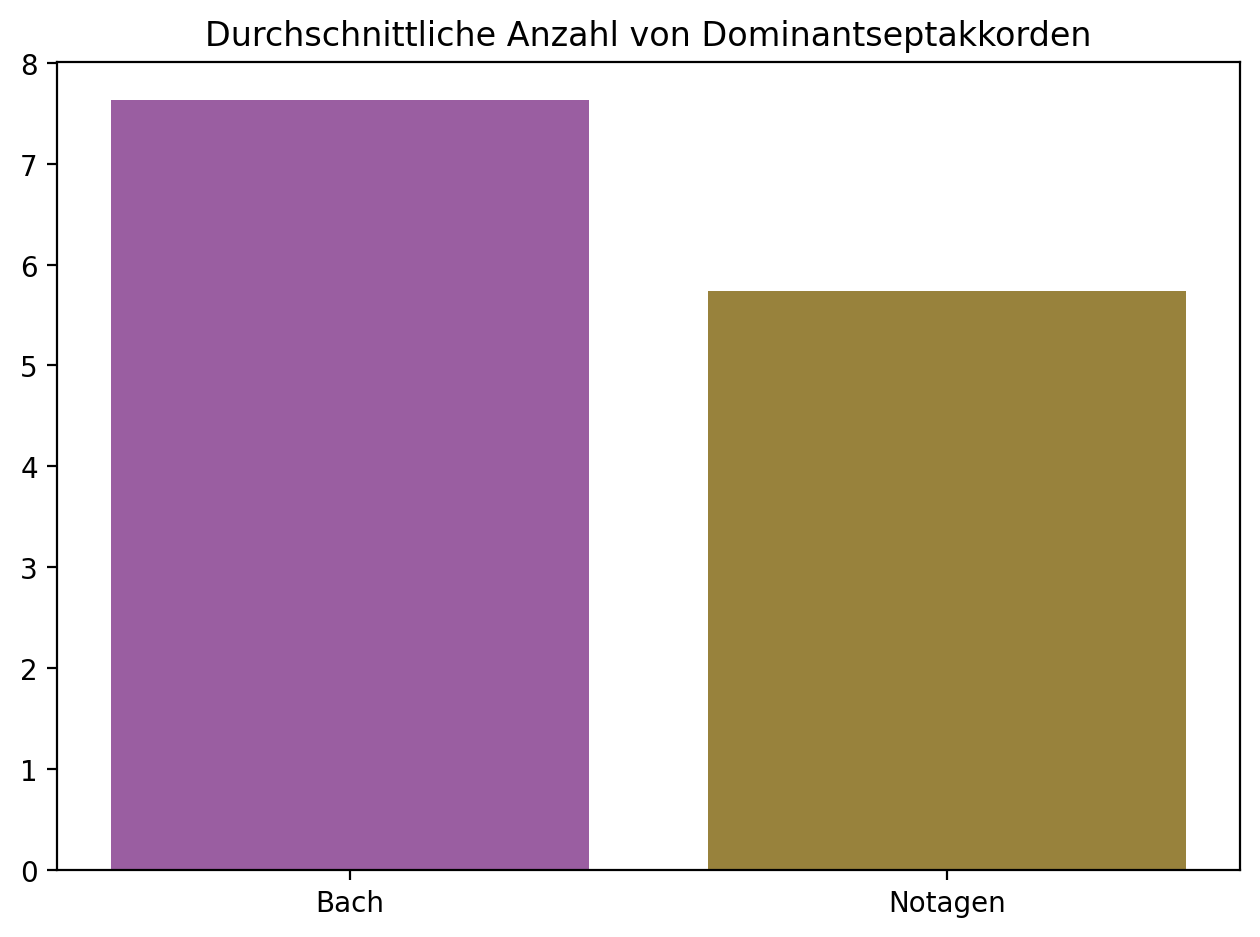

In [18]:
"""
4. Dominant seventh chords
"""
import music21 as m21
import numpy as np
# NOTAGEN

d7_count_ai = 0
d7_ai_chord_list = [] #do we want/need a list? maybe we could specify what d7 chords occur often?
for path in notagen_corpus.getPaths():
    score = corpus.parse(path)
    scoreChords = score.chordify()
    for chord in scoreChords.recurse().getElementsByClass(m21.chord.Chord):
        if chord.isDominantSeventh():
            d7_ai_chord_list.append([chord.beatStr, chord])
            d7_count_ai += 1
        else:
            continue


# BACH
d7_count = 0
d7_bach_chord_list = []

bach_chorales = m21.corpus.chorales.Iterator()
for piece in bach_chorales:
    pieceChords = piece.chordify()
    for chord in pieceChords.recurse().getElementsByClass(m21.chord.Chord):
        if chord.isDominantSeventh():
            d7_bach_chord_list.append([chord.beatStr, chord])
            d7_count += 1
        else:
            continue

print(f"Total D7-Chord Count (Bach): {d7_count}")
print(f"Total D7-Chord Count (Notagen): {d7_count_ai}")
x  = np.array(["Bach", "Notagen"])
y = np.array([d7_count / 371, d7_count_ai / 100]) ## relative counts
plt.bar(x, y, color=COLORS)
plt.title("Durchschnittliche Anzahl von Dominantseptakkorden")
plt.tight_layout()
#plt.savefig("dominant_chords.pdf")
plt.show()

In [21]:
import pandas as pd
df_bach = pd.DataFrame(bach_snippets).T.astype(int)
df_notagen = pd.DataFrame(notagen_snippets).T.astype(int)

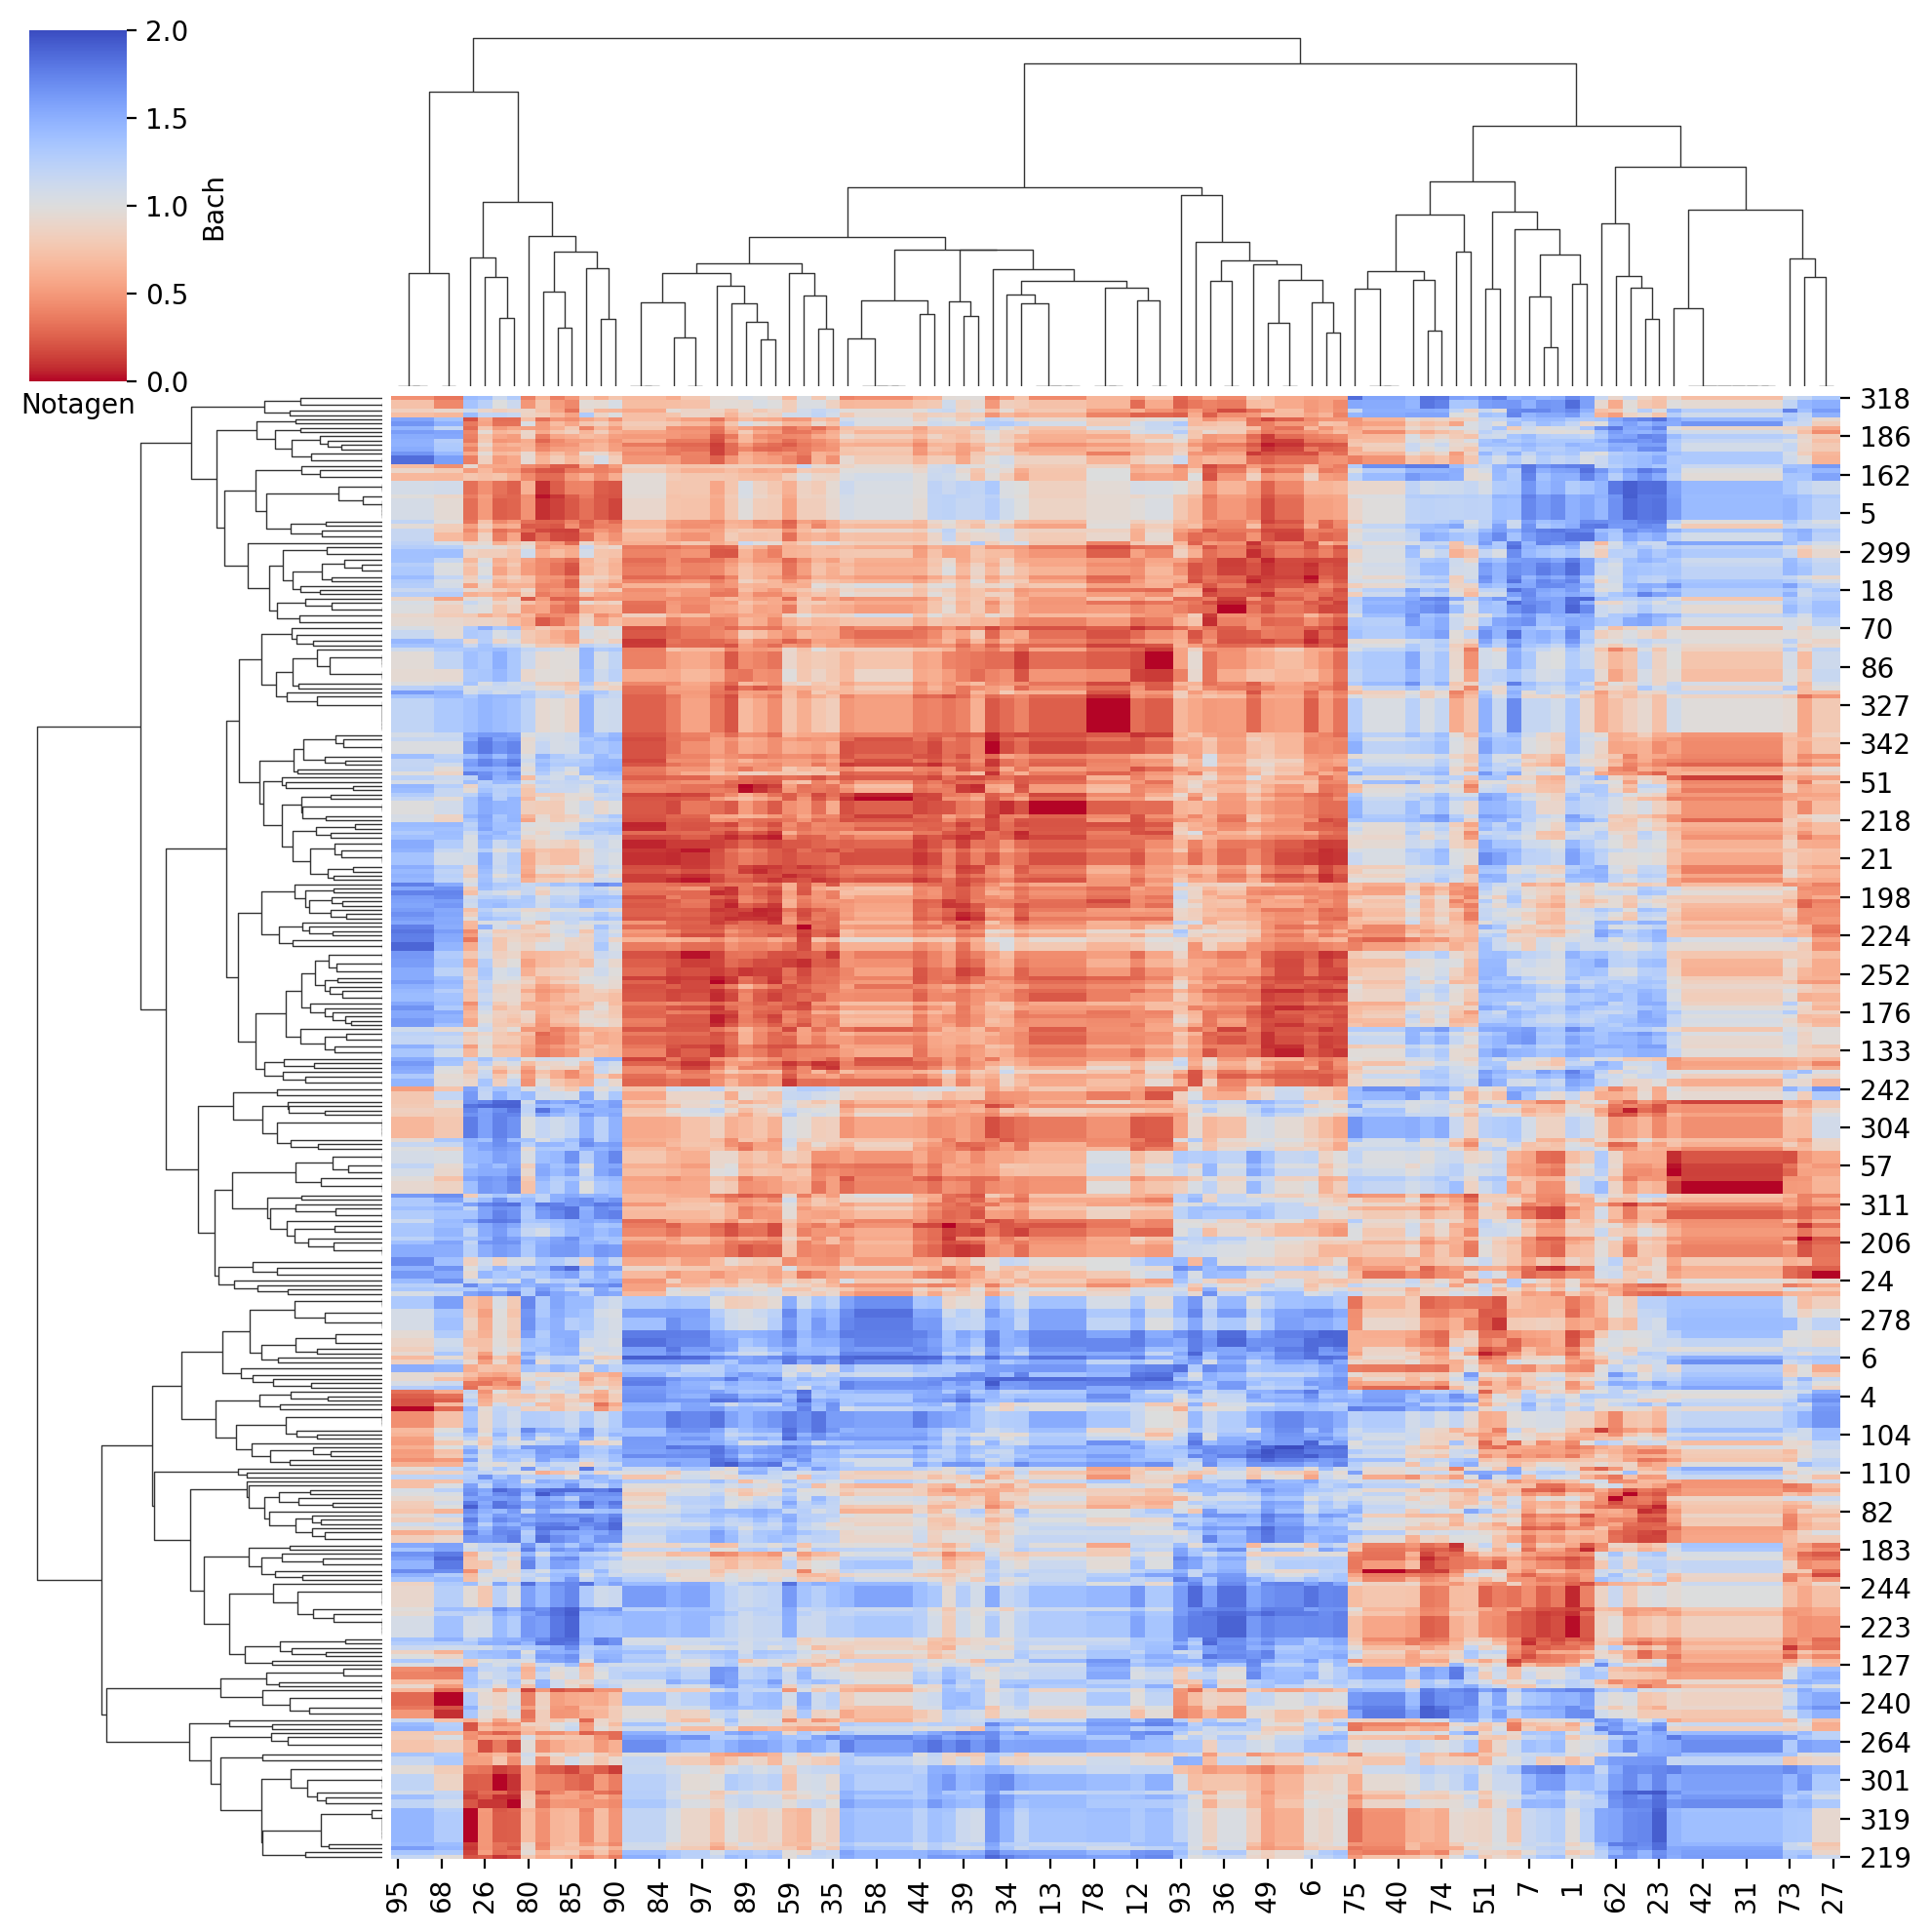

In [27]:
from sklearn.metrics import pairwise_distances
import seaborn as sns

dists = pairwise_distances(df_bach.values, Y=df_notagen.values, metric="correlation")

sns.clustermap(dists, cmap="coolwarm_r")
plt.xlabel("Notagen")
plt.ylabel("Bach")
plt.show()

In [ ]:
"""
5. Check for parallel fifths
"""
# figuredBass.checker.parallelFifths?


In [ ]:
"""
Phrase starting on upbeat / downbeats
"""

## The following cells were saved after updating our colab-document, no further use for now

In [ ]:
"""
getting the Measures + Notes for every piece in the Notagen corpus + Average Values
"""
total_notes = 0
total_notes_list = []
total_measures = 0
for i in range(1, 101):
  ai_piece = m21.converter.parse(f"{DATA}/output{i}.xml")
  ai_piece_notes = len(ai_piece.recurse().notes)
  sopr = ai_piece.parts[0]
  ai_piece_measures = sopr.getElementsByClass("Measure")
  total_notes += ai_piece_notes
  total_notes_list.append(ai_piece_notes)
  total_measures += len(ai_piece_measures)
  print(f" Total Notes for Piece {i}: {ai_piece_notes}, Number of Measures: {len(ai_piece_measures)}", end="")
  print("")
print(f"Average Notes per piece: {total_notes / 100:.2f}")
print(f"Average Measures per piece: {total_measures / 100:.2f}")

variance = np.var(total_notes_list)
stand_dev = np.sqrt(variance)

print(f"Die Standardabweichung beträgt {stand_dev:.2f}")

In [ ]:
import numpy as np
"""
J: Getting the Number of Notes and Number of Measures from every original Bach chorale + Average values
"""
bach_chorales = m21.corpus.chorales.Iterator()
total_notes_list = []
total_notes = 0
total_measures = 0
for piece in bach_chorales:
    piece_notes = len(piece.recurse().notes)                                # notes of a piece
    sopr = piece.parts[0]
    piece_measures = sopr.getElementsByClass("Measure")                     # getting the length (measure number) of a piece
    total_notes += piece_notes                                              # sums up notes for all
    total_notes_list.append(piece_notes)
    total_measures += len(piece_measures)                                   # sums up measures for all iterations
    print(f" Total Notes for {piece.metadata.title}: {piece_notes}, Number of Measures: {len(piece_measures)}", end="")
    print("")
print(f"Average Notes per piece: {total_notes / len(bach_chorales):.2f}")
print(f"Average Measures per piece: {total_measures / len(bach_chorales):.2f}")

variance = np.var(total_notes_list)
stand_dev = np.sqrt(variance)
print(f"Die Standardabweichung der Noten beträgt {stand_dev}")


# TESTS

In [ ]:
import music21 as m21
piece = corpus.parse("schoenberg/opus19", 6)
piece.id = "Original"

pieceChords = piece.chordify()
pieceChords.id = "Chords"

for chord in pieceChords.recurse().getElementsByClass(m21.chord.Chord):
    chord.closedPosition(forceOctave=4, inPlace=True)

piece.insert(0, pieceChords)
piece.show()
# Why does an error occur when calling it as musicxml

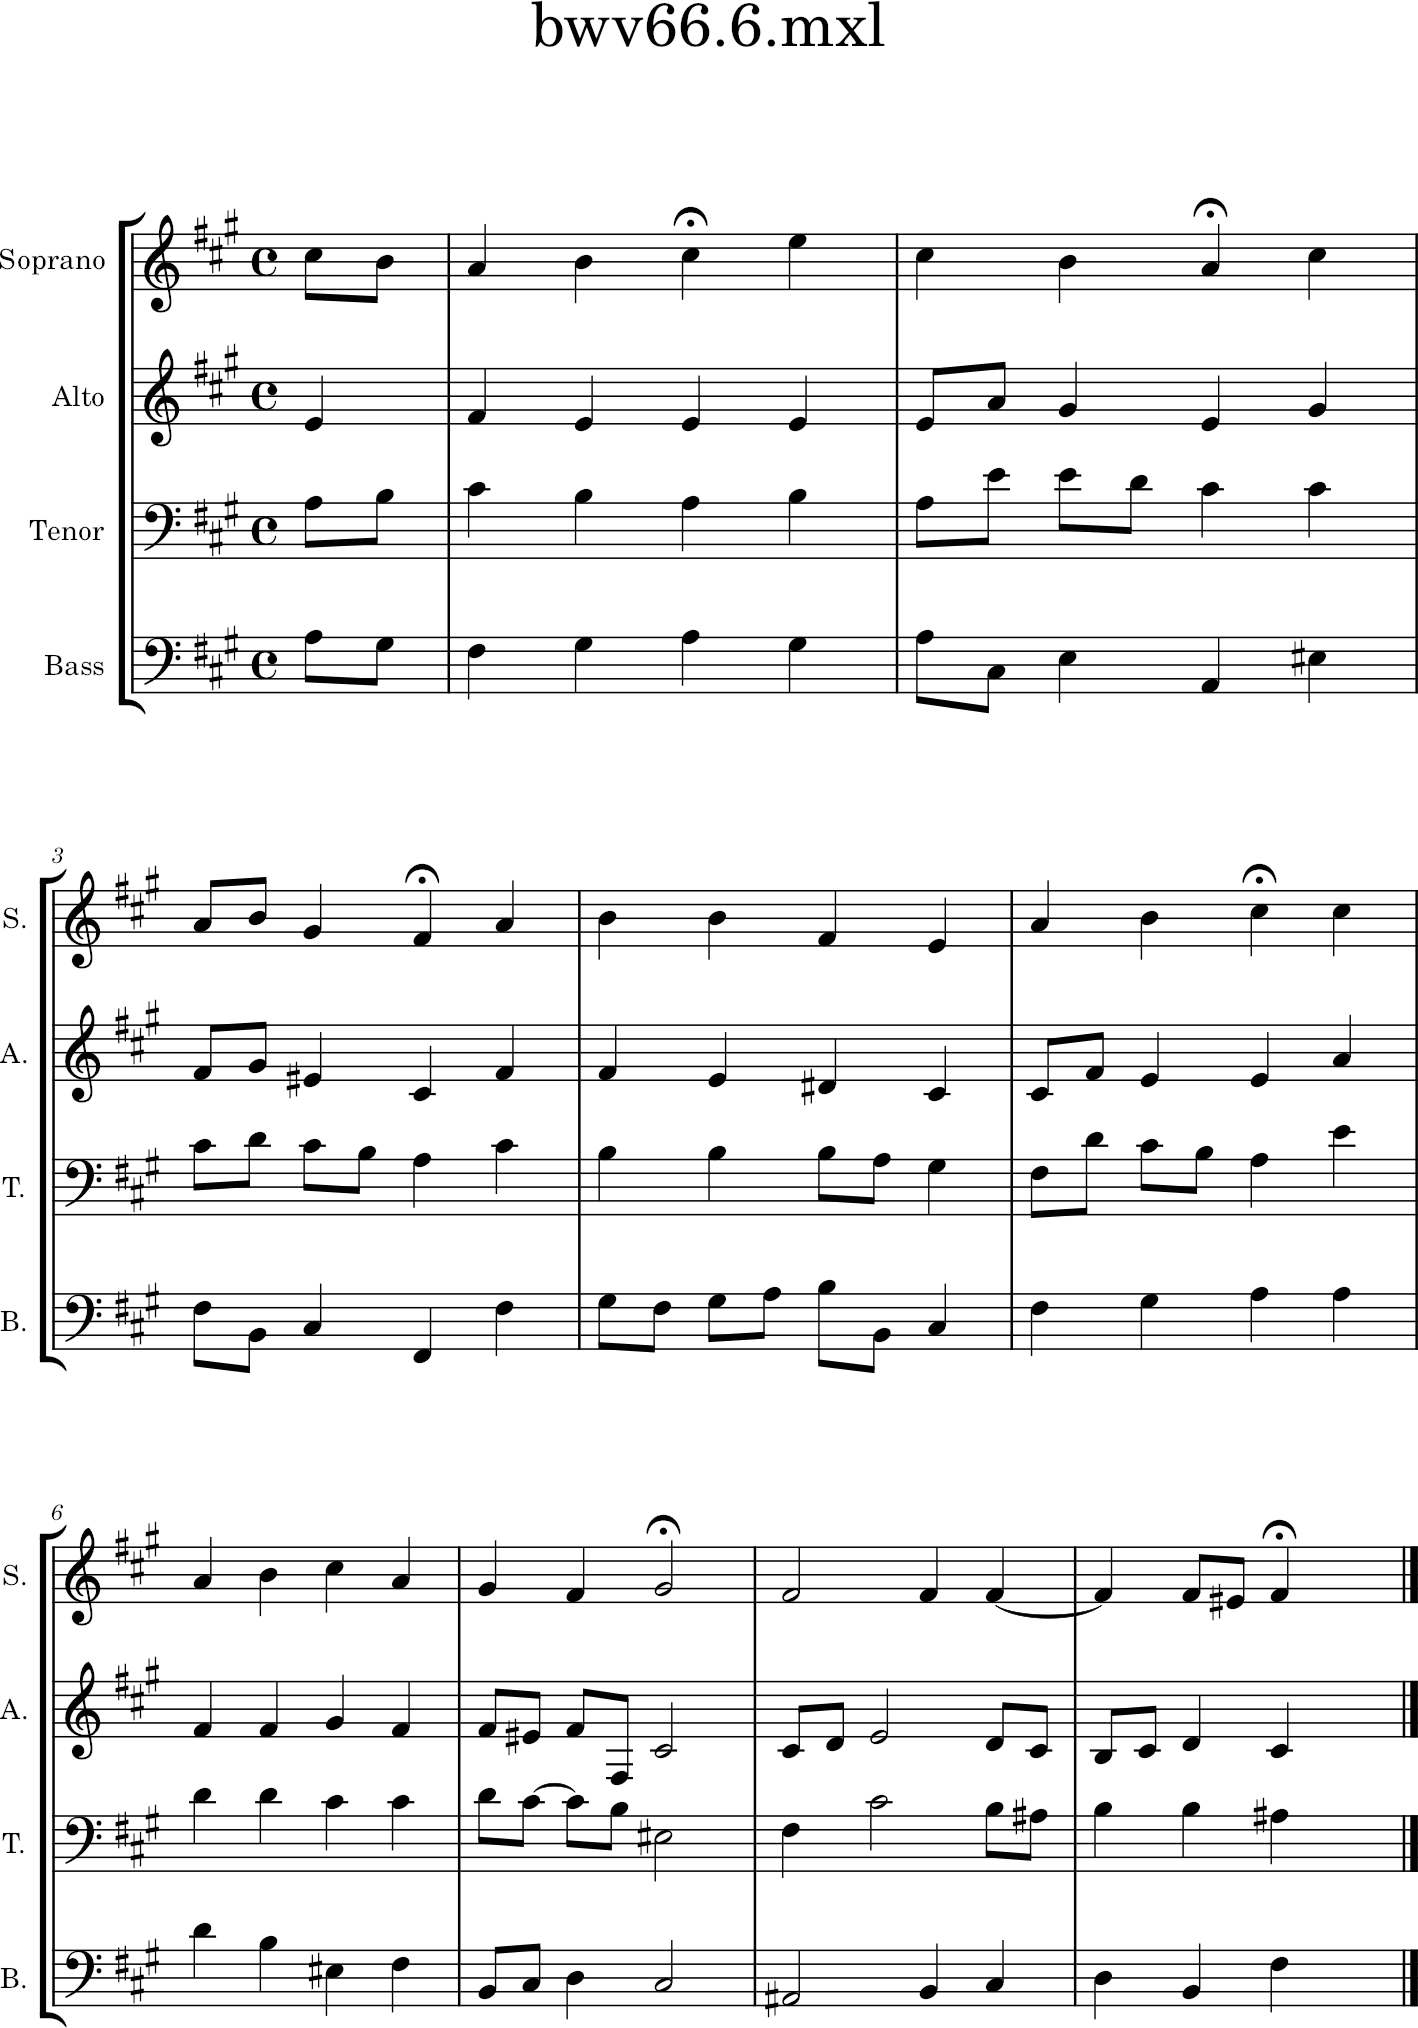

In [80]:
bach = corpus.parse("bach/bwv66.6")
bach.show()

## A score is a type of *stream*, a stream is a type of *container*

In [22]:
list(bach)

 <music21.stream.Part Soprano>,
 <music21.stream.Part Alto>,
 <music21.stream.Part Tenor>,
 <music21.stream.Part Bass>,
 <music21.layout.StaffGroup <music21.stream.Part Soprano><music21.stream.Part Alto><music21.stream.Part Tenor><music21.stream.Part Bass>>]

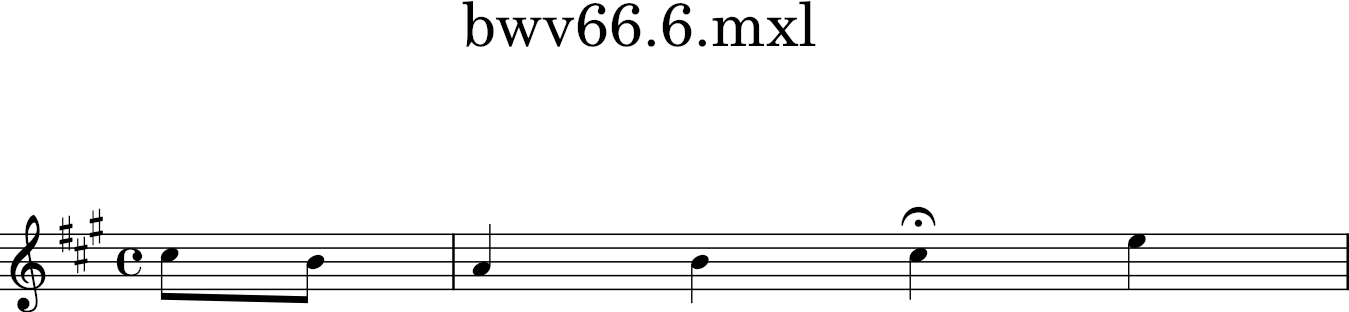

In [87]:
sopr = bach.parts[0]
alt = bach.parts[1]
tenor = bach.parts[2]
bass = bach.parts[3]
pickup = list(sopr)[1]
sopr.measures(0,1).show()

In [86]:
soprNotes = list(sopr.recurse().getElementsByClass(m21.note.Note))
altNotes = list(alt.recurse().getElementsByClass(m21.note.Note))
tenorNotes = list(tenor.recurse().getElementsByClass(m21.note.Note))
bassNotes = list(bass.recurse().getElementsByClass(m21.note.Note))


VoiceQuartet = m21.voiceLeading.VoiceLeadingQuartet(
    soprNotes,
    altNotes,
    tenorNotes,
    bassNotes
)
print(VoiceQuartet.v1n1)

None
